# Tutorial 3: Autoencoder Compression and Latent-Space Exploration

**Organizer**: Dr. José I. Robledo

Professor Balseiro Institute, Bariloche Atomic centre, Argentina (CAB-CNEA)

Researcher at the National Scientific Council of Argentina (CONICET)

---

## Goal of this tutorial

In this notebook we will study a simple **unsupervised learning** problem using simulated inelastic neutron scattering spectra.

The goal is to train an **autoencoder** that:
- compresses each powder INS spectrum into a low-dimensional latent vector, and
- reconstructs the spectrum from that latent representation.

Unlike the classification and regression tutorials, here we do not predict an external target. Instead, the model learns to represent the structure already present in the spectrum itself.

As in the previous tutorials, we will use the database that is provided in the Open Dataset published in [Scientific Data: "A database of synthetic inelastic neutron scattering spectra from molecules and crystals" (Scientific Data volume 10, Article number: 54 (2023) )](https://www.nature.com/articles/s41597-022-01926-x).

The `crystals` folder contains one subfolder per material, and each subfolder includes the simulated neutron-scattering files associated with that crystal. In this tutorial we will work directly with the powder INS map stored in `powder_2Dmesh_coh_0K.csv`.

### Specific objectives:

- how to load a 2D INS spectrum from CSV
- how to convert each spectrum into a fixed-size image for machine learning
- how to train a compact autoencoder with PyTorch
- how to compare original and reconstructed spectra
- how to project the latent space into two dimensions
- how to interpret smooth interpolations in latent space

---


## General Imports


## Preparing a dataset for Machine Learning

### Shared helper functions

The common functions used in these tutorials are in the module `tnt2026_utils.py`.
That file contains the dataset-parsing, spectrum-loading, resizing, normalization, splitting, and PCA helper functions that are reused across the three provided notebooks.

Now we will focus only on the autoencoder and latent-space exploration.

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

from tnt2026_utils import (
    build_crystal_index,
    dataframe_train_test_split,
    infer_project_root,
    load_spectrum_grid,
    make_image_tensor,
    pca_project,
    seed_everything,
)

seed_everything(42)
PROJECT_ROOT = infer_project_root()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

### Extraction and loading of input features

Here, each crystal contributes one input:
- the powder INS intensity map $S(Q,E)$

Since this is an autoencoder, the target is simply the same spectrum again.
So the model learns a function of the form:

$$
\hat{x} = f_w(x)
$$

where:
- $x$ is the INS spectrum represented as an image,
- $w$ are the trainable parameters of the encoder and decoder,
- $\hat{x}$ is the reconstructed spectrum.

This makes the problem conceptually simple and useful for a first introduction to unsupervised learning in neutron science.


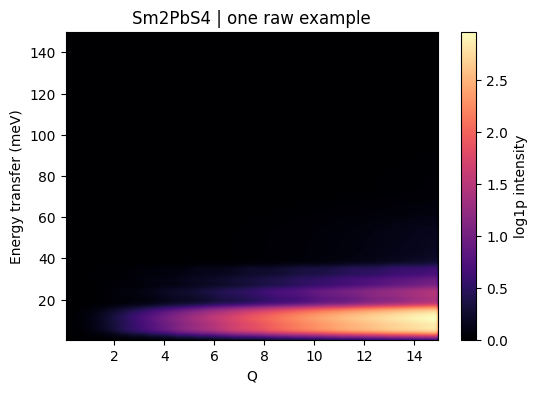

In [2]:
MAX_SAMPLES = 2000
IMAGE_SIZE = (128, 128)
TEST_SIZE = 0.3
BATCH_SIZE = 32
EPOCHS = 40
LR = 1e-3
LATENT_DIM = 128
PATIENCE = 8

index = build_crystal_index(
    PROJECT_ROOT / "crystals",
    PROJECT_ROOT / "crystals.dat",
    max_samples=MAX_SAMPLES,
    seed=42,
)
train_df, test_df = dataframe_train_test_split(
    index,
    test_size=TEST_SIZE,
    seed=42,
    stratify_col="crystal_system",
)

sample = train_df.sample(1, random_state=0).iloc[0]
q_values, e_values, image = load_spectrum_grid(sample["csv_path"])
plt.figure(figsize=(6, 4))
plt.imshow(
    np.log1p(image).T,
    origin="lower",
    aspect="auto",
    extent=[q_values.min(), q_values.max(), e_values.min(), e_values.max()],
    cmap="magma",
)
plt.title(f"{sample['formula']} | one raw example")
plt.xlabel("Q")
plt.ylabel("Energy transfer (meV)")
plt.colorbar(label="log1p intensity")
plt.show()


## Preprocessing the INS spectra

As before, Neural networks need all inputs to have the same size, so each $S(Q,E)$ spectrum is resized to a fixed image shape. We control this with the variable `IMAGE_SIZE`.

We then apply the standard transformation:

$$x_{log} = \log(1 + x)$$

This compresses very large intensities and makes the scale easier to learn.

Finally, we divide by the maximum transformed intensity in the training set so that the inputs lie approximately between 0 and 1.
This makes the reconstruction problem more stable and matches well with the bounded output of the decoder.

The latent vector has length `LATENT_DIM`, so the autoencoder is forced to compress a large image into a much smaller representation.
That compression is what makes the latent space interesting to explore afterwards.

In [3]:
X_train = make_image_tensor(train_df, size=IMAGE_SIZE, base_transform="log1p")
X_test = make_image_tensor(test_df, size=IMAGE_SIZE, base_transform="log1p")

train_scale = float(X_train.max().item())
X_train = X_train / max(train_scale, 1e-6)
X_test = X_test / max(train_scale, 1e-6)

train_loader = DataLoader(TensorDataset(X_train, X_train), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, X_test), batch_size=BATCH_SIZE, shuffle=False)

print("Input tensor shape:", tuple(X_train.shape))
print("Latent dimension:", LATENT_DIM)
print("Compression ratio:", int(np.prod(IMAGE_SIZE) / LATENT_DIM))
print("Training intensity scale:", train_scale)


Input tensor shape: (1401, 1, 128, 128)
Latent dimension: 128
Compression ratio: 128
Training intensity scale: 4.221749305725098


## Autoencoder Model and Loss

We use a convolutional autoencoder, because the INS spectrum is a 2D image-like object.

The encoder progressively reduces the image to a latent vector, and the decoder reconstructs the image from that vector.

To train the model, we need a loss that rewards good reconstructions. In this tutorial we will keep things as simple as possible and use the **mean squared error**:

$$
MSE = \frac{1}{N} \sum_i (\hat{x}_i - x_i)^2
$$

where:
- $x$ is the original spectrum,
- $\hat{x}$ is the reconstructed spectrum.

A lower reconstruction loss means that the reconstructed image is closer to the original one.
This is the most standard and easiest reconstruction loss to explain.


In [14]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder_cnn = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
        )
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 32 * 32, 1024),
            nn.ReLU(),
            nn.Linear(1024, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim),
        )
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1024),
            nn.ReLU(),
            nn.Linear(1024, 32 * 32 * 32),
            nn.ReLU(),
        )
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(8, 1, kernel_size=3, padding=1),
            nn.Sigmoid(),
        )

    def encode(self, x):
        h = self.encoder_cnn(x)
        return self.encoder_fc(h)

    def decode(self, z):
        h = self.decoder_fc(z).view(-1, 32, 32, 32)
        return self.decoder_cnn(h)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decode(z)
        return recon, z


model = Autoencoder(latent_dim=LATENT_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()


def run_epoch(loader, training):
    model.train(training)
    total_loss = 0.0
    total_items = 0

    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(training):
            recon, _ = model(xb)
            loss = loss_fn(recon, yb)
        if training:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * len(xb)
        total_items += len(xb)

    return total_loss / total_items


history = []
best_state = None
best_test_loss = float("inf")
epochs_without_improvement = 0

for epoch in range(1, EPOCHS + 1):
    train_loss = run_epoch(train_loader, training=True)
    test_loss = run_epoch(test_loader, training=False)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
        }
    )
    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch:02d}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

history_df = pd.DataFrame(history)
history_df


epoch 01 | train_loss=0.0522 | test_loss=0.0158
epoch 02 | train_loss=0.0108 | test_loss=0.0086
epoch 03 | train_loss=0.0072 | test_loss=0.0067
epoch 04 | train_loss=0.0059 | test_loss=0.0056
epoch 05 | train_loss=0.0048 | test_loss=0.0044
epoch 06 | train_loss=0.0041 | test_loss=0.0040
epoch 07 | train_loss=0.0037 | test_loss=0.0039
epoch 08 | train_loss=0.0035 | test_loss=0.0035
epoch 09 | train_loss=0.0032 | test_loss=0.0033
epoch 10 | train_loss=0.0031 | test_loss=0.0032
epoch 11 | train_loss=0.0030 | test_loss=0.0031
epoch 12 | train_loss=0.0029 | test_loss=0.0030
epoch 13 | train_loss=0.0029 | test_loss=0.0029
epoch 14 | train_loss=0.0027 | test_loss=0.0029
epoch 15 | train_loss=0.0027 | test_loss=0.0029
epoch 16 | train_loss=0.0027 | test_loss=0.0028
epoch 17 | train_loss=0.0026 | test_loss=0.0027
epoch 18 | train_loss=0.0024 | test_loss=0.0025
epoch 19 | train_loss=0.0023 | test_loss=0.0024
epoch 20 | train_loss=0.0023 | test_loss=0.0023
epoch 21 | train_loss=0.0022 | test_loss

,epoch,train_loss,test_loss
0,1,0.052193,0.015804
1,2,0.010819,0.008578
2,3,0.007170,0.006749
3,4,0.005936,0.005590
4,5,0.004840,0.004397
5,6,0.004067,0.003980
6,7,0.003655,0.003903
7,8,0.003483,0.003536
8,9,0.003230,0.003255
9,10,0.003094,0.003207


In [21]:
CONTINUE_EPOCHS = 20
for epoch in range(1, CONTINUE_EPOCHS + 1):
    epoch += EPOCHS
    train_loss = run_epoch(train_loader, training=True)
    test_loss = run_epoch(test_loader, training=False)
    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "test_loss": test_loss,
        }
    )
    print(
        f"epoch {epoch:02d} | train_loss={train_loss:.4f} | test_loss={test_loss:.4f}"
    )

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= PATIENCE:
            print(f"Early stopping at epoch {epoch:02d}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

EPOCHS += CONTINUE_EPOCHS
history_df = pd.DataFrame(history)
history_df

epoch 41 | train_loss=0.0016 | test_loss=0.0017
epoch 42 | train_loss=0.0015 | test_loss=0.0018
epoch 43 | train_loss=0.0015 | test_loss=0.0018
epoch 44 | train_loss=0.0015 | test_loss=0.0017
epoch 45 | train_loss=0.0014 | test_loss=0.0017
epoch 46 | train_loss=0.0014 | test_loss=0.0017
epoch 47 | train_loss=0.0014 | test_loss=0.0017
epoch 48 | train_loss=0.0013 | test_loss=0.0017
epoch 49 | train_loss=0.0013 | test_loss=0.0018
epoch 50 | train_loss=0.0013 | test_loss=0.0016
epoch 51 | train_loss=0.0012 | test_loss=0.0016
epoch 52 | train_loss=0.0012 | test_loss=0.0016
epoch 53 | train_loss=0.0012 | test_loss=0.0015
epoch 54 | train_loss=0.0012 | test_loss=0.0015
epoch 55 | train_loss=0.0011 | test_loss=0.0015
epoch 56 | train_loss=0.0011 | test_loss=0.0015
epoch 57 | train_loss=0.0011 | test_loss=0.0014
epoch 58 | train_loss=0.0010 | test_loss=0.0014
epoch 59 | train_loss=0.0010 | test_loss=0.0014
epoch 60 | train_loss=0.0010 | test_loss=0.0014


,epoch,train_loss,test_loss
0,1,0.052193,0.015804
1,2,0.010819,0.008578
2,3,0.007170,0.006749
3,4,0.005936,0.005590
4,5,0.004840,0.004397
5,6,0.004067,0.003980
6,7,0.003655,0.003903
7,8,0.003483,0.003536
8,9,0.003230,0.003255
9,10,0.003094,0.003207


## Results

The reconstruction figure compares:
- the original spectrum,
- the reconstructed spectrum,
- the absolute error between them.

For a good autoencoder:
- the reconstructed spectrum should keep the main intensity bands,
- the strongest spectral features should remain visible,
- the error map should be small in the regions that matter most physically.

If the reconstruction looks too smooth, that usually means the latent bottleneck is too small, the image was resized too aggressively, or the decoder is not strong enough.
In this simplified tutorial, however, the main goal is to understand the workflow rather than to optimize every detail of the reconstruction.


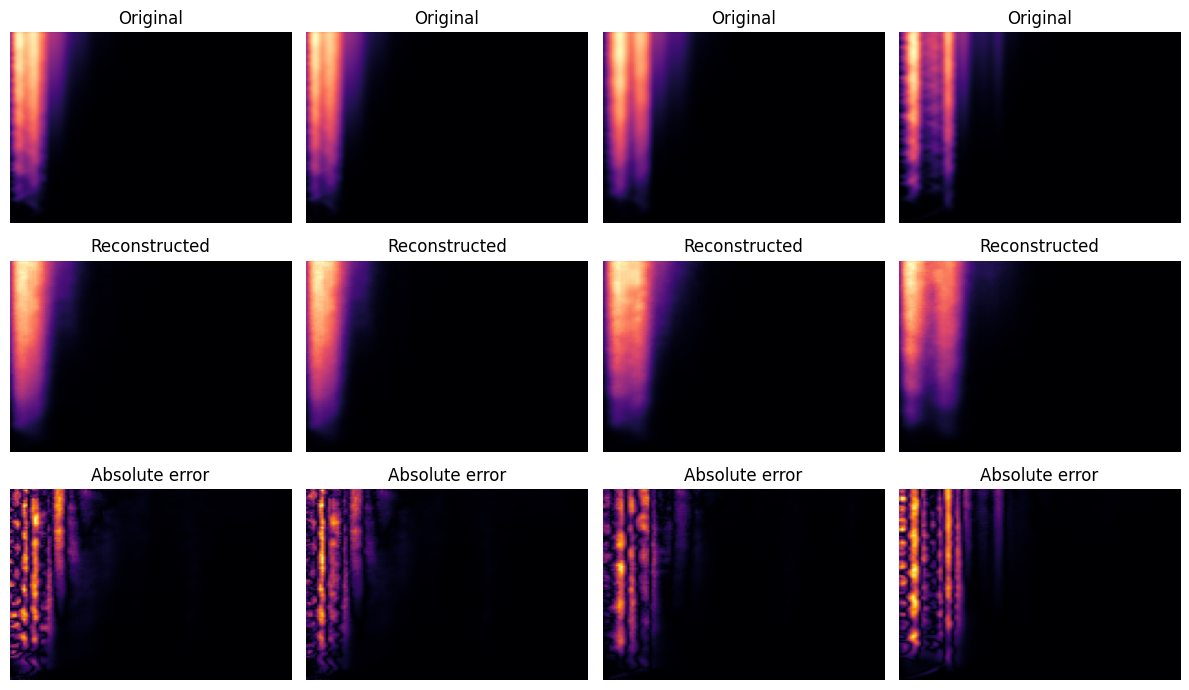

Latent vector shape for one batch: (4, 128)


In [22]:
model.eval()
sample_batch = X_test[10:10+4].to(device)
with torch.no_grad():
    recon_batch, latent_batch = model(sample_batch)

originals = (sample_batch.cpu().numpy() * train_scale)
reconstructions = (recon_batch.cpu().numpy() * train_scale)
errors = np.abs(originals - reconstructions)

fig, axes = plt.subplots(3, 4, figsize=(12, 7))
for i in range(4):
    axes[0, i].imshow(originals[i, 0], origin="lower", aspect="auto", cmap="magma")
    axes[0, i].set_title("Original")
    axes[0, i].axis("off")

    axes[1, i].imshow(reconstructions[i, 0], origin="lower", aspect="auto", cmap="magma")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

    axes[2, i].imshow(errors[i, 0], origin="lower", aspect="auto", cmap="inferno")
    axes[2, i].set_title("Absolute error")
    axes[2, i].axis("off")

plt.tight_layout()
plt.show()

print("Latent vector shape for one batch:", tuple(latent_batch.shape))


## Exploring the Latent Space

Once the autoencoder is trained, each crystal spectrum is represented by a latent vector.
These vectors live in a high-dimensional space, which is difficult to inspect directly.

To visualize them, we project the latent vectors into two dimensions using PCA.
This allows us to ask simple questions such as:
- do similar materials cluster together?
- are there clear outliers?
- does the latent space seem smooth or fragmented?

This is one of the main reasons autoencoders are useful: they provide not only a reconstruction model, but also a compact representation that can be explored afterwards.


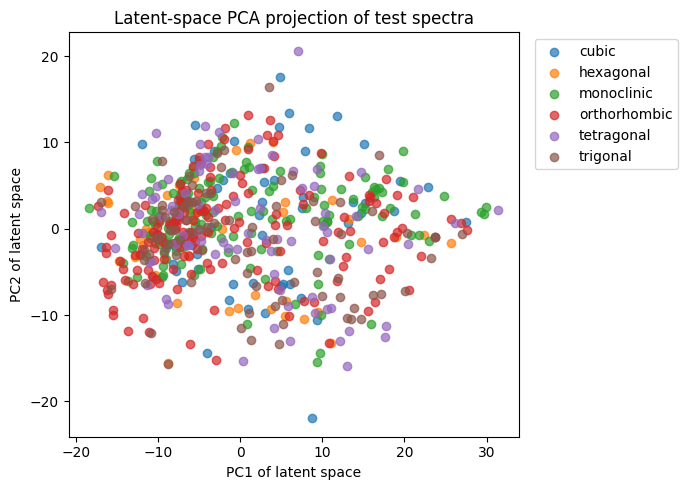

,pc1,pc2,crystal_system,formula
0,-5.228344,-2.978693,cubic,F2Ba
1,11.194501,3.351878,hexagonal,P3Cd3Pr
2,-9.864370,-0.926995,trigonal,O6Na2GeTe
3,-7.301998,-1.332912,trigonal,B4O12Sc3La
4,4.792672,17.569880,cubic,F6NaP


In [24]:
model.eval()
all_latents = []
all_labels = []
all_formulas = []

for row, x in zip(test_df.itertuples(), X_test):
    with torch.no_grad():
        z = model.encode(x.unsqueeze(0).to(device)).cpu().numpy()[0]
    all_latents.append(z)
    all_labels.append(row.crystal_system)
    all_formulas.append(row.formula)

latent_matrix = np.stack(all_latents)
latent_xy, _ = pca_project(latent_matrix, n_components=5)
latent_df = pd.DataFrame(
    {
        "pc1": latent_xy[:, 0],
        "pc2": latent_xy[:, 1],
        "crystal_system": all_labels,
        "formula": all_formulas,
    }
)

plt.figure(figsize=(7, 5))
for crystal_system, group in latent_df.groupby("crystal_system"):
    plt.scatter(group["pc1"], group["pc2"], alpha=0.7, label=crystal_system)
plt.xlabel("PC1 of latent space")
plt.ylabel("PC2 of latent space")
plt.title("Latent-space PCA projection of test spectra")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

latent_df.head()


## Latent Interpolation

A second way to inspect the latent space is to interpolate between two latent vectors.

If the latent space is meaningful, then intermediate points between two spectra should decode into intermediate spectral patterns rather than random images.

This gives an intuitive way to see whether the model has learned a smooth internal representation of the INS spectra.


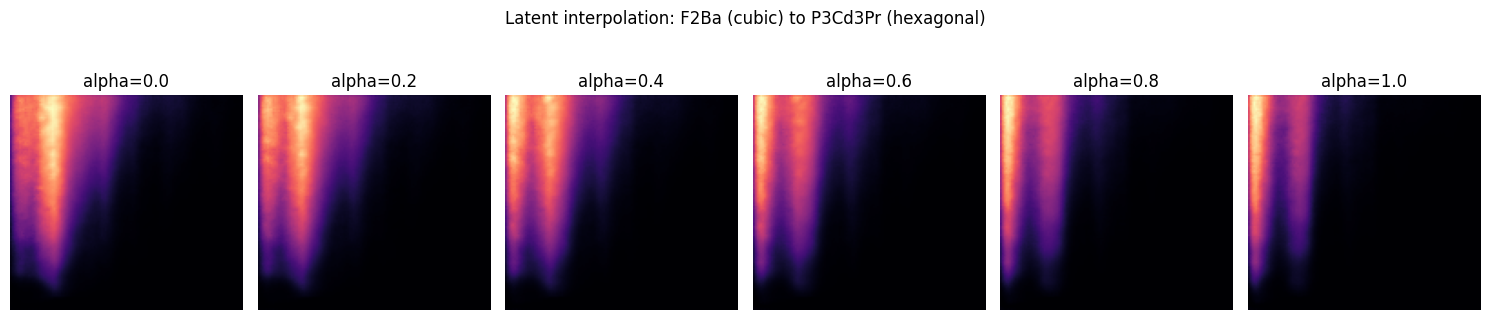

In [25]:
systems = test_df["crystal_system"].unique().tolist()
start_row = test_df.iloc[0]
end_row = test_df.loc[test_df["crystal_system"] != start_row["crystal_system"]].iloc[0]

start_x = X_test[test_df.index[test_df["crystal_id"] == start_row["crystal_id"]][0]].unsqueeze(0).to(device)
end_x = X_test[test_df.index[test_df["crystal_id"] == end_row["crystal_id"]][0]].unsqueeze(0).to(device)

with torch.no_grad():
    z0 = model.encode(start_x)
    z1 = model.encode(end_x)

steps = torch.linspace(0, 1, 6, device=device)
interp_images = []
with torch.no_grad():
    for alpha in steps:
        z = (1 - alpha) * z0 + alpha * z1
        interp_images.append(model.decode(z).cpu().numpy()[0, 0] * train_scale)

fig, axes = plt.subplots(1, len(interp_images), figsize=(15, 3))
for ax, alpha, image in zip(axes, steps.cpu().numpy(), interp_images):
    ax.imshow(image, origin="lower", aspect="auto", cmap="magma")
    ax.set_title(f"alpha={alpha:.1f}")
    ax.axis("off")

plt.suptitle(
    f"Latent interpolation: {start_row['formula']} ({start_row['crystal_system']}) "
    f"to {end_row['formula']} ({end_row['crystal_system']})",
    y=1.05,
)
plt.tight_layout()
plt.show()


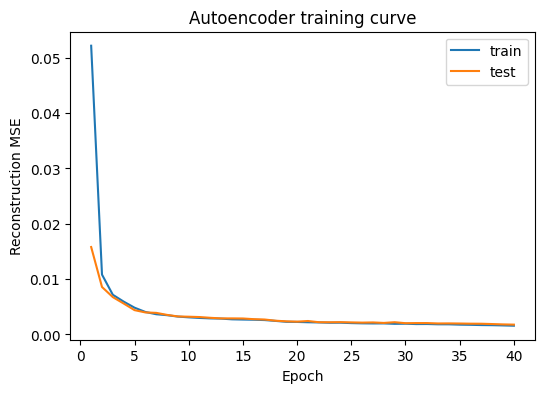

In [19]:
plt.figure(figsize=(6, 4))
plt.plot(history_df["epoch"], history_df["train_loss"], label="train")
plt.plot(history_df["epoch"], history_df["test_loss"], label="test")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction MSE")
plt.title("Autoencoder training curve")
plt.legend()
plt.show()


## Conclusion

In this notebook we built an unsupervised learning pipeline for neutron-scattering data. We converted each powder INS spectrum into a normalized image, trained a convolutional autoencoder to reconstruct those images, and then explored the resulting latent space with PCA and interpolation to show how the workflow would be.

We have seen that:
- raw neutron-scattering spectra can be converted into image-like ML inputs,
- an autoencoder can learn a compact latent representation of INS spectra, although it needs tunning before obtaining acceptable results,
- reconstruction quality can be assessed visually and with a simple loss curve,
- if the latent space is relevant, then it can be explored to study similarity and smooth transitions between spectra.
